# A gentle introduction to Machine Learning

---
## What is AI? What is Machine Learning? (5 Min)

<p align="center">
  <img src="https://raw.githubusercontent.com/Hunter174/GentleIntroToML/main/assets/ai-ml-dl_bubbles.png" width="400"/>
</p>

**Artificial Intelligence (AI):** Systems that perform tasks requiring human-like intelligence (reasoning, decision-making, perception).

**Machine Learning (ML):** A subset of AI where systems learn patterns from data to make predictions or decisions.

**Deep Learning (DL):** A subset of ML using neural networks to model complex patterns in large datasets.

**Generative AI (GenAI):** Models that create new content (text, images, code) based on learned patterns.

---
## Types of Machine Learning

There are two main types:

### 1. Supervised Learning
We give the model inputs AND correct answers.

### 2. Unsupervised Learning
The model finds patterns without answers.

<p align="center">
  <img src="https://raw.githubusercontent.com/Hunter174/GentleIntroToML/main/assets/supervised-vs-unsupervised_learning.png" width="400"/>
</p>


## Problem 1

We are going to visualize -> Train -> Predict
Given a popular tabular database
- Input: House size (square feet)
- Output: Price

We’ll train the model using example data.

In [15]:
from sklearn.datasets import load_iris

# Load the dataset
iris_data = load_iris(as_frame=True)
df = iris_data.frame

# Load the first n=5 samples
print(df.head())
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [16]:
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop(columns=["target"])
y = df["target"]

# Standardize features (important for PCA)
X = StandardScaler().fit_transform(X)

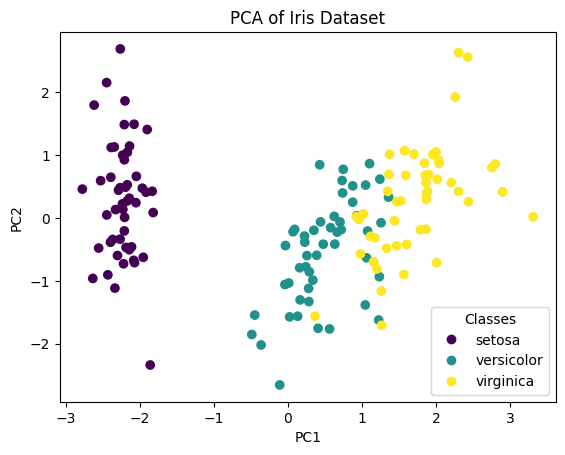

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# we are going to "Explore" the data to understand what it looks like
# PCA → 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.figure()

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis"
)

# Legend with class names
handles, _ = scatter.legend_elements()
labels = iris_data.target_names
plt.legend(handles, labels, title="Classes")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Iris Dataset")

plt.show()

# Why do we need a train/test split?

When we train a model, it learns patterns from the data we give it.

If we evaluate the model on the **same data it was trained on**, it can appear to perform very well—even if it has simply memorized the data.

To properly measure performance, we split the data into:

- **Training set** → used to train the model
- **Test set** → used to evaluate how well the model generalizes to new, unseen data

---

# Key Idea

> We test on data the model has never seen before to estimate real-world performance.

In [18]:
# Split the data into a train set and a test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% for testing
    random_state=42 # Ensures reproducibility
)

# Logistic Regression (Classification)

Logistic regression is used for **classification problems**.
Instead of predicting a number, it predicts the **probability of a class**.

---

# One-vs-Rest (OvR) for Multiple Classes

How do we handle more than two classes?

**One-vs-Rest (OvR)** breaks a multi-class problem into multiple binary problems.

For each class:
- Treat that class as **“positive”**
- Treat all other classes as **“negative”**
- Train a separate model

Example (Iris with 3 classes):
- Model 1: Setosa vs Not Setosa
- Model 2: Versicolor vs Not Versicolor
- Model 3: Virginica vs Not Virginica

Each model outputs a probability.
We select the class with the **highest probability**.

---

# Key Idea

> Multi-class classification = multiple binary classifiers working together

In [20]:
# Logistic Regression (OvR - One vs Rest)

from sklearn.linear_model import LogisticRegression

# Initialize model
model = LogisticRegression(max_iter=200)

# Train the model
model.fit(X_train, y_train)

# Evaluate
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0


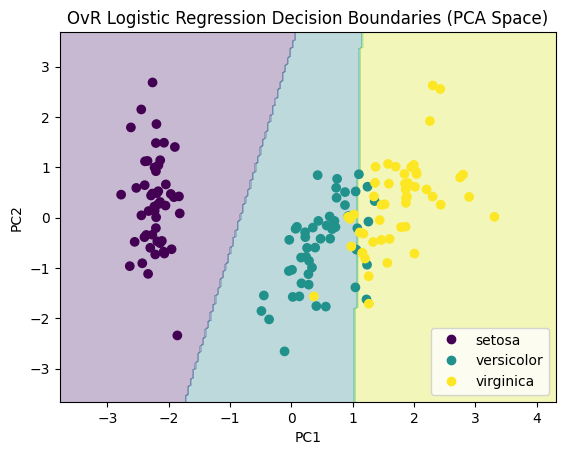

In [24]:
#@title Visualize decision boundaries (in PCA space)

import numpy as np
import matplotlib.pyplot as plt

# --- Step 2: Train model on PCA data ---
model = LogisticRegression(max_iter=200)
model.fit(X_pca, y)

# --- Step 3: Create mesh grid ---
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# --- Step 4: Predict over grid ---
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# --- Step 5: Plot ---
plt.figure()

# Decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

# Original points
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis"
)

# Legend
handles, _ = scatter.legend_elements()
plt.legend(handles, ["setosa", "versicolor", "virginica"])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("OvR Logistic Regression Decision Boundaries (PCA Space)")

plt.show()

## What is a Model?

A model is a mathematical function that maps inputs to outputs.

In this case, we will use a straight line:

- Input → house size
- Output → predicted price

The model will learn the best line that fits the data.

In [ ]:
# Predictions for existing data
y_pred = model.predict(X)

plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred, label="Model Prediction")

plt.xlabel("House Size (sq ft)")
plt.ylabel("Price ($1000s)")
plt.title("Model Fit")

plt.legend()
plt.show()

In [ ]:
# Predict price for a new house
new_size = np.array([[1800]])

predicted_price = model.predict(new_size)

print("Predicted price for 1800 sq ft house:", predicted_price[0], "(in $1000s)")

## Key Takeaways

- Machine learning finds patterns in data
- We trained a model using example data
- The model learned a relationship between size and price
- Now it can make predictions on new data

## Try It Yourself

- Change the dataset values
- Add more data points
- Predict prices for different house sizes

Example:
Try predicting for 1000 sq ft or 2500 sq ft.